## Extract singlelook/multilooked intensity data from NISAR L/S-band Compact-pol GCOV data #### 

#### Compact-pol has RH-RV or RHRH or RVRV modes 

In [1]:
""" 
import required packages
"""

import os
import matplotlib.pyplot as plt
import numpy as np
from osgeo import gdal
import polsartools as pst
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module='pyproj')


In [2]:
""" 

Function to display images

"""

def plot_images(*filenames, lower_percentile=2, upper_percentile=98, max_cols=4):
    def compute_vmin_vmax(data):
        data_no_nan = data[np.isfinite(data)]
        vmin = np.percentile(data_no_nan, lower_percentile)
        vmax = np.percentile(data_no_nan, upper_percentile)
        return vmin, vmax

    num_images = len(filenames)

    if num_images == 1:
        # Single image case
        data = pst.read_rst(filenames[0])
        data[data==0]=np.nan
        vmin, vmax = compute_vmin_vmax(data)

        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(data, vmin=vmin, vmax=vmax)
        ax.set_title(os.path.basename(filenames[0]))
        fig.colorbar(im, ax=ax)
        plt.tight_layout()
        plt.show()
    else:
        # Multiple image case
        ncols = min(max_cols, num_images)
        nrows = int(np.ceil(num_images / ncols))

        fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
        axes = np.array(axes).reshape(-1)  # Flatten in case it's a 2D grid

        for i, filename in enumerate(filenames):
            data = pst.read_rst(filename)
            data[data==0]=np.nan
            vmin, vmax = compute_vmin_vmax(data)
            ax = axes[i]
            im = ax.imshow(data, vmin=vmin, vmax=vmax)
            ax.set_title(os.path.basename(filename))
            fig.colorbar(im, ax=ax)

        for j in range(num_images, len(axes)):
            axes[j].axis('off')

        plt.tight_layout()
        plt.show()


#### Extract singlelook/multilooked intensity data from NISAR GCOV data
##### using **`polsartools.import_nisar_gcov`** function, [click here for documentation](https://polsartools.readthedocs.io/en/latest/files/sensors/nisar.html#gslc-nisar-gcov) or run `print(polsartools.import_nisar_gcov.__.doc__)`

Data downloaded from Bhoonidhi-ISRO

In [15]:
inFile =r"D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001.h5"

# The following function extracts elements of C2 matirx from NISAR Compact-pol GCOV data. 
# Provide path to the NISAR GCOV .h5 file.

##------------------------------------------------------------------------
# GCOV products have a square cell of 10x10 to 20x20m 
# Change the azimuth and range looks to 1x1 when process full resolution
# Else process at reduced resolution by applying multilooking e.g., 5x5 both in azimuth and range direction

pst.import_nisar_gcov(inFile, azlks=5,rglks=5,
                      fmt='tif', # output format tif//bin
                      cog=False, ovr=[2, 4, 8, 16], # Cloud Optimized geotif -COG prameters
                      comp=False, # Tiff compression (optional)
                      out_dir=None, #path to out_dir (optional)
                     ) 

Detected S-band polarization channels: ['RH' 'RV']
Extracting elements...


Processing chunks: 100%|███████████████████████████████████████████████████████████| 1122/1122 [00:13<00:00, 84.17it/s]


Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\C11.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\C12_real.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\C12_imag.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\C22.tif
Execution time for import_nisar_gcov: 28.00 seconds


#### Generate a quick look RGB from Intesity images

RGB image saved as D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\RGB3.png
Execution time for rgb_dp: 3.00 seconds


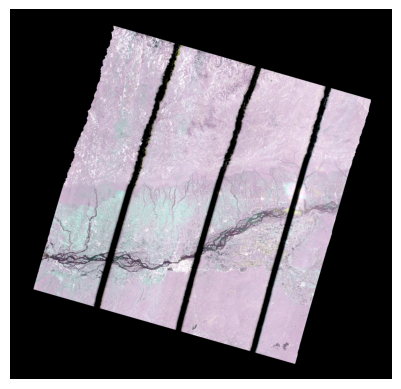

In [16]:
C2Folder = os.path.join(inFile.split('.h5')[0],'C2R')

pst.rgb_dp(C2Folder,type=3) #Types indicate diffent band combinations 


## Decomposition of Compact-pol C2 matrix
#### m-$\chi$ decomposition

In [9]:
pst.m_chi(C2Folder)


Progress: 100%|█████████████████████████████████████████████████████████████████████| 49/49 [00:02<00:00, 22.26block/s]


Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Ps_m_chi.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Pd_m_chi.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Pv_m_chi.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\m_cp.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\chi_cp.tif
Execution time for m_chi: 4.00 seconds


#### Display decomposition powers individually as in-line plot

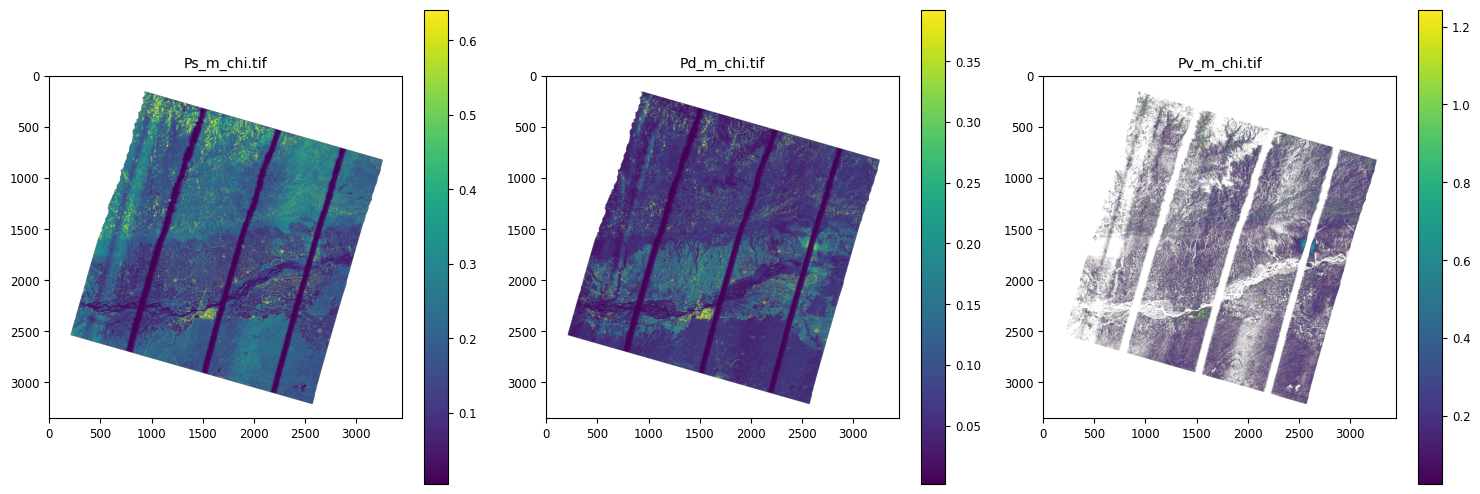

In [10]:
plot_images(C2Folder+'/Ps_m_chi.tif',
            C2Folder+'/Pd_m_chi.tif',
            C2Folder+'/Pv_m_chi.tif',
            lower_percentile=2, upper_percentile=98)

#### Display decomposition powers as RGB

RGB image saved as D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\RGB.png
Execution time for rgb: 3.00 seconds


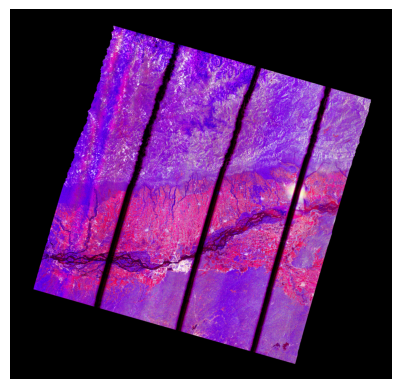

In [11]:
blue = os.path.join(C2Folder,'Ps_m_chi.tif')
red = os.path.join(C2Folder,'Pd_m_chi.tif')
green = os.path.join(C2Folder,'Pv_m_chi.tif')

pst.rgb(red,green,blue)

## Decomposition of Compact-pol C2 matrix
#### Model free decomposition MF3CC

In [12]:
pst.mf3cc(C2Folder)

Progress: 100%|█████████████████████████████████████████████████████████████████████| 49/49 [00:02<00:00, 21.54block/s]


Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Ps_mf3cc.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Pd_mf3cc.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Pv_mf3cc.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Theta_CP_mf3cc.tif
Execution time for mf3cc: 4.00 seconds


#### Display decomposition powers individually as in-line plot

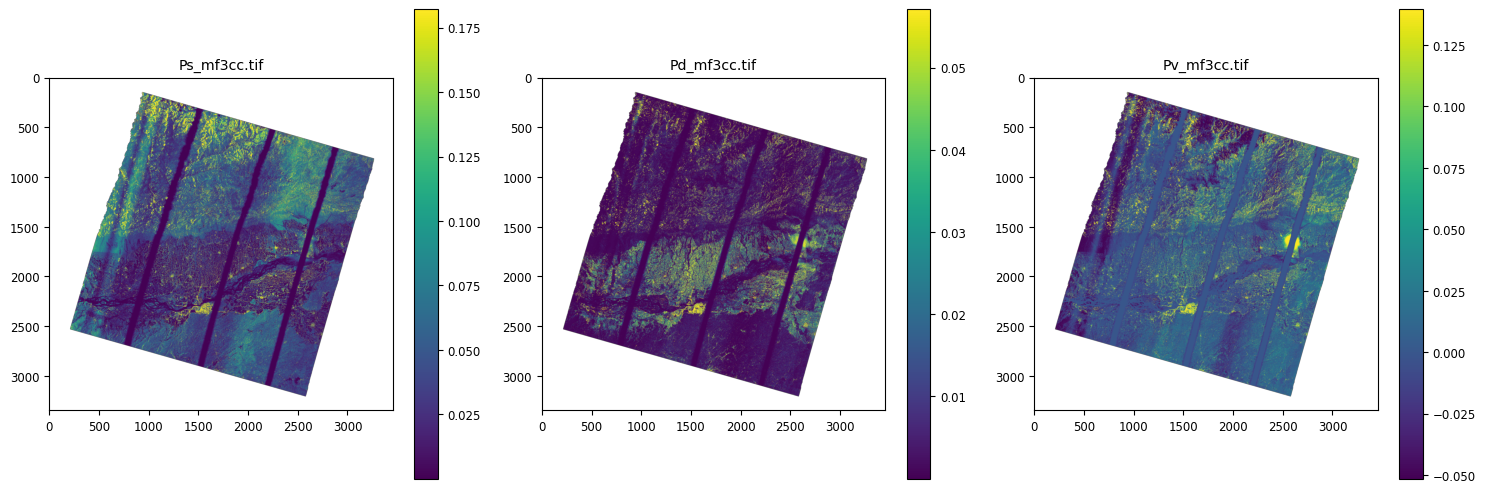

In [18]:
plot_images(C2Folder+'/Ps_mf3cc.tif',
            C2Folder+'/Pd_mf3cc.tif',
            C2Folder+'/Pv_mf3cc.tif',
            lower_percentile=5, upper_percentile=95)

## Entropy H of Compact-pol C2 matrix

In [13]:
pst.h_alpha_dp(C2Folder)

Progress: 100%|█████████████████████████████████████████████████████████████████████| 49/49 [00:03<00:00, 12.25block/s]


Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\Hdp.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\alphadp.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\e1_norm.tif
Saved file D:\Dipankar\NISAR_Datasets\NISAR_MG2026\NISAR_S2_PR_GCOV_031_091_D_075_2500_CRNA_A_20260924T123346_20260924T123423_P00500_M_F_I_001\C2R\e2_norm.tif
Execution time for h_alpha_dp: 6.00 seconds


#### Plotting H-$\theta_{CP}$ and zones

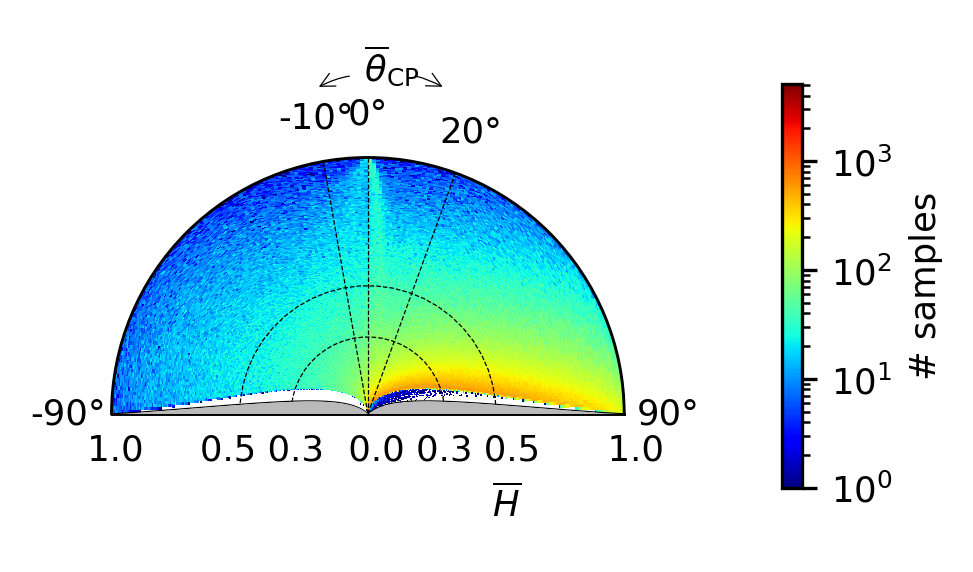

In [14]:
h_path =  os.path.join(C2Folder,'Hdp.tif')
theta_path = os.path.join(C2Folder,'Theta_CP_mf3cc.tif')

pst.plot_h_theta_cp(h_path, theta_path, ppath="HT_plot.png", cmap='jet', cbar=True, norm='log')